# 02 — Exploratory Data Analysis (EDA)
Project FORESIGHT — Week 2, Day 6-8

**Goal:** find real demand patterns in the cleaned dataset — top movers, dead stock,
seasonality, and category trends — and turn them into plain-language business insights
for the D2 memo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/processed/analysis_ready.csv', parse_dates=['date', 'launch_date'])
print(df.shape)
df.head(3)

Matplotlib is building the font cache; this may take a moment.


(129130, 21)


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,list_price,flag_bad_economics,week,month,season,is_holiday,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-01-01,SKU0001,17,103794.86,6105.58,0,Decor,Wall Art,2024-01-01,3151.81,6105.58,False,1,1,Winter,1,NaN,168.0,242.0,14.0,132.0
1,2024-01-02,SKU0001,11,67161.38,6105.58,0,Decor,Wall Art,2024-01-01,3151.81,6105.58,False,1,1,Winter,0,NaN,168.0,242.0,14.0,132.0
2,2024-01-03,SKU0001,18,109900.44,6105.58,0,Decor,Wall Art,2024-01-01,3151.81,6105.58,False,1,1,Winter,0,NaN,168.0,242.0,14.0,132.0


## 1. Top movers & dead stock
Which SKUs sell the most, and which barely sell at all?

In [3]:
sku_totals = df.groupby('sku_id').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    category=('category', 'first'),
).sort_values('total_units', ascending=False)

print("Top 10 movers:")
display(sku_totals.head(10))

print("\nBottom 10 (dead stock candidates):")
display(sku_totals.tail(10))

dead_stock_threshold = sku_totals['total_units'].quantile(0.10)
n_dead = (sku_totals['total_units'] <= dead_stock_threshold).sum()
print(f"\n{n_dead} SKUs ({n_dead/len(sku_totals)*100:.1f}%) fall in the bottom 10% by units sold "
      f"(<= {dead_stock_threshold:.0f} units total) — dead-stock candidates.")

Top 10 movers:


,total_units,total_revenue,category
sku_id,,,
SKU0073,24723,6.881519e+07,Small Appliances
SKU0181,24036,1.439244e+07,Furniture
SKU0164,23964,9.330694e+07,Decor
SKU0196,23462,1.545122e+08,Furniture
SKU0145,23377,2.408228e+07,Small Appliances
SKU0058,23344,1.072852e+08,Small Appliances
SKU0117,22624,3.847600e+07,Furniture
SKU0167,21982,1.341657e+08,Textiles
SKU0017,21720,1.285100e+08,Furniture



Bottom 10 (dead stock candidates):


,total_units,total_revenue,category
sku_id,,,
SKU0086,1783,6909759.44,Textiles
SKU0095,1708,3714636.45,Furniture
SKU0139,1686,775378.84,Small Appliances
SKU0111,1654,8458275.67,Decor
SKU0161,1369,1889830.60,Textiles
SKU0094,1345,11655746.28,Textiles
SKU0066,1090,2850990.92,Furniture
SKU0016,1026,4807676.28,Furniture
SKU0040,940,1055253.15,Lighting



20 SKUs (10.0%) fall in the bottom 10% by units sold (<= 2912 units total) — dead-stock candidates.


## 2. Category-level performance
Which categories drive the most revenue vs volume?

,total_units,total_revenue,n_skus,revenue_per_sku
category,,,,
Furniture,596269,2.177034e+09,56,38875608.0
Small Appliances,478129,1.947357e+09,43,45287368.0
Decor,479141,1.855651e+09,48,38659400.0
Lighting,300077,1.208944e+09,30,40298146.0
Textiles,208310,7.853806e+08,23,34146984.0


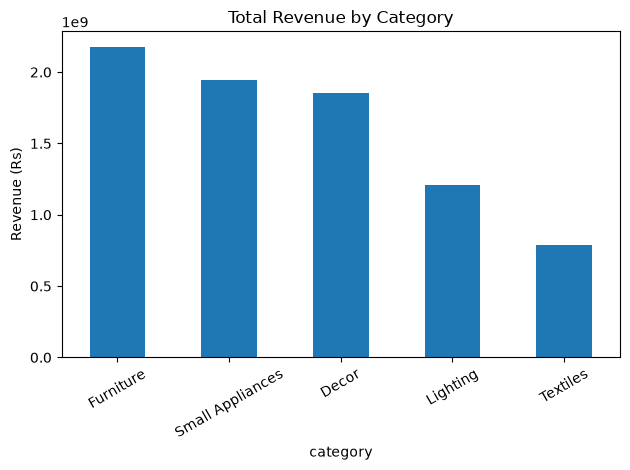

In [4]:
category_summary = df.groupby('category').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    n_skus=('sku_id', 'nunique'),
).sort_values('total_revenue', ascending=False)
category_summary['revenue_per_sku'] = (category_summary['total_revenue'] / category_summary['n_skus']).round(0)
display(category_summary)

category_summary['total_revenue'].plot(kind='bar', title='Total Revenue by Category', ylabel='Revenue (Rs)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Seasonality
Does demand rise/fall with month, season, or day of week?

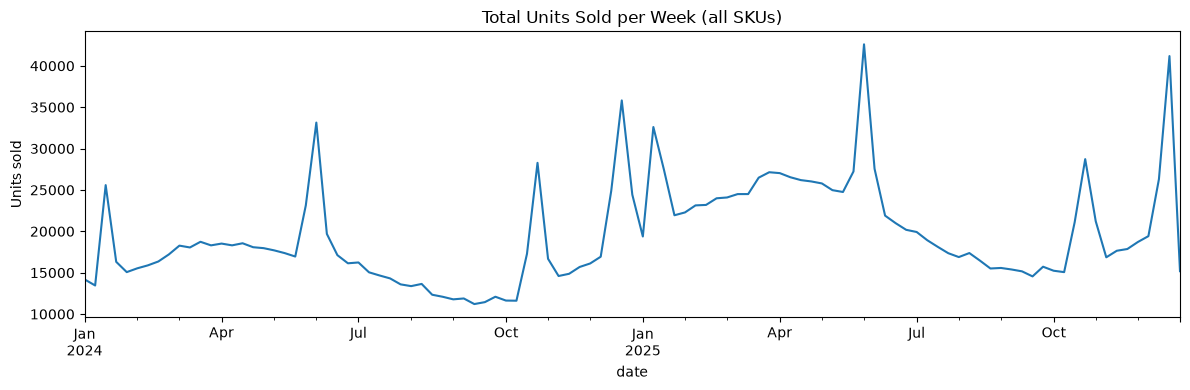

Average daily units sold, by calendar month:


month
1     18.68
2     17.39
3     18.83
4     18.63
5     17.56
6     20.44
7     13.31
8     11.78
9     10.45
10    12.91
11    13.64
12    19.07
Name: units_sold, dtype: float64

In [5]:
weekly_demand = df.groupby(df['date'].dt.to_period('W'))['units_sold'].sum()
weekly_demand.index = weekly_demand.index.to_timestamp()

plt.figure(figsize=(12,4))
weekly_demand.plot(title='Total Units Sold per Week (all SKUs)')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

monthly_avg = df.groupby('month')['units_sold'].mean()
print("Average daily units sold, by calendar month:")
display(monthly_avg.round(2))

Average units sold, by day of week:


dow
Monday       14.73
Tuesday      14.40
Wednesday    14.38
Thursday     14.14
Friday       14.14
Saturday     19.93
Sunday       20.09
Name: units_sold, dtype: float64

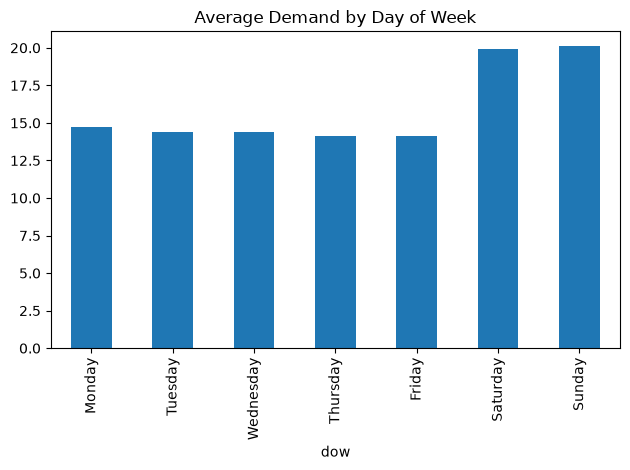

In [6]:
dow_avg = df.assign(dow=df['date'].dt.day_name()).groupby('dow')['units_sold'].mean()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = dow_avg.reindex(dow_order)
print("Average units sold, by day of week:")
display(dow_avg.round(2))
dow_avg.plot(kind='bar', title='Average Demand by Day of Week')
plt.tight_layout()
plt.show()

## 4. Promotion effect
Do promo days actually lift demand? By how much?

In [7]:
promo_effect = df.groupby('promo_flag')['units_sold'].mean()
lift_pct = (promo_effect[1] / promo_effect[0] - 1) * 100
print(f"Avg units sold on non-promo days: {promo_effect[0]:.2f}")
print(f"Avg units sold on promo days:     {promo_effect[1]:.2f}")
print(f"Promo lift: {lift_pct:.1f}%")

Avg units sold on non-promo days: 14.53
Avg units sold on promo days:     26.63
Promo lift: 83.3%


## 5. Holiday effect

In [8]:
holiday_effect = df.groupby('is_holiday')['units_sold'].mean()
holiday_lift = (holiday_effect[1] / holiday_effect[0] - 1) * 100
print(f"Avg units sold on regular days: {holiday_effect[0]:.2f}")
print(f"Avg units sold on holidays:     {holiday_effect[1]:.2f}")
print(f"Holiday lift: {holiday_lift:.1f}%")

Avg units sold on regular days: 15.88
Avg units sold on holidays:     21.82
Holiday lift: 37.4%


## 6. Demand variability by SKU
SKUs with highly erratic demand are harder to forecast and riskier to stock.

In [9]:
sku_daily = df.groupby(['sku_id','date'])['units_sold'].sum().reset_index()
variability = sku_daily.groupby('sku_id')['units_sold'].agg(['mean','std'])
variability['cv'] = (variability['std'] / variability['mean']).round(2)  # coefficient of variation
variability = variability.sort_values('cv', ascending=False)
print("Top 10 most volatile SKUs (highest coefficient of variation):")
display(variability.head(10))

Top 10 most volatile SKUs (highest coefficient of variation):


,mean,std,cv
sku_id,,,
SKU0016,7.832061,5.178584,0.66
SKU0198,22.857651,15.024065,0.66
SKU0099,15.811388,10.127580,0.64
SKU0139,2.512668,1.614136,0.64
SKU0130,4.496580,2.835379,0.63
SKU0191,15.142271,9.376099,0.62
SKU0192,2.893297,1.763277,0.61
SKU0066,1.876076,1.148520,0.61
SKU0079,14.157319,8.656845,0.61


## 7. Summary of insights (fill in with your own numbers from above)

Write 3+ plain-language, business-relevant findings here for the D2 memo. Example structure:

1. **[Category] drives X% of revenue** from only Y SKUs — concentration risk / opportunity.
2. **Demand peaks in [month/season]**, roughly Xx the off-season average — plan stock ahead of that window.
3. **Promotions lift demand by X%** — factor this into the forecast as a feature.
4. **N SKUs are dead stock candidates** (bottom 10% by volume) — early markdown candidates.
5. **[SKU/category] shows highly volatile demand** (high CV) — flag as lower-confidence in the forecast.
